In [27]:
import sys
import os
base_dir = os.path.dirname(__file__) if '__file__' in globals() else os.getcwd()
sys.path.append(os.path.abspath(os.path.join(base_dir, '..')))
import argparse
from tqdm import tqdm
from torch import optim
from MvDST_gpu_beta import MvDST
from utils import *
import torch.nn.functional as F
import pandas as pd
from utils import get_logger
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
import os
import scipy.sparse as sparse
import anndata
import seaborn as sns
import time
sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3
sns.set_style("white")
np.random.seed(0)

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.23.5 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [28]:
section_id = "151675"
input_dir = os.path.join('..\\Data\\', section_id)
adata = sc.read_visium(path=input_dir, count_file=section_id + '_filtered_feature_bc_matrix.h5')
adata.var_names_make_unique()
sc.pp.calculate_qc_metrics(adata, inplace=True)
adata = adata[:, adata.var['total_counts'] > 100]
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=3000)
hvg_filter = adata.var['highly_variable']
sc.pp.normalize_total(adata, inplace=True)
adata = adata[:, hvg_filter]  
cluster_num =7

reading ..\Data\151675\151675_filtered_feature_bc_matrix.h5
 (0:00:00)


2025-06-17 21:59:42 - PIL.PngImagePlugin - DEBUG: - STREAM b'IHDR' 16 13
2025-06-17 21:59:42 - PIL.PngImagePlugin - DEBUG: - STREAM b'IHDR' 16 13
2025-06-17 21:59:42 - PIL.PngImagePlugin - DEBUG: - STREAM b'IDAT' 41 32768
2025-06-17 21:59:42 - PIL.PngImagePlugin - DEBUG: - STREAM b'IDAT' 41 32768
2025-06-17 21:59:42 - PIL.PngImagePlugin - DEBUG: - STREAM b'IHDR' 16 13
2025-06-17 21:59:42 - PIL.PngImagePlugin - DEBUG: - STREAM b'IHDR' 16 13
2025-06-17 21:59:42 - PIL.PngImagePlugin - DEBUG: - STREAM b'IDAT' 41 32768
2025-06-17 21:59:42 - PIL.PngImagePlugin - DEBUG: - STREAM b'IDAT' 41 32768


extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)


In [29]:
Ann_df = pd.read_csv(os.path.join('..\\Data', section_id, section_id+'_truth.txt'), sep='\t', header=None, index_col=0)
Ann_df.columns = ['Ground Truth']
adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth']

In [30]:
from image_feature import ImageFeature, image_crop
from pathlib import Path
save_path = 'results'
save_path_image_crop = Path(os.path.join(save_path, 'image_crop', f'{section_id}'))
save_path_image_crop.mkdir(parents=True, exist_ok=True)
adata = image_crop(adata, crop_size=112, save_path=save_path_image_crop, verbose=False)
adata = ImageFeature(adata, pca_components=200, verbose=True, seeds=2023).extract_image_features()
adata

Tiling Image: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]
Extract image feature:   0%|                                                                                                                        [ time left: ? ]2025-06-17 22:00:01 - PIL.PngImagePlugin - DEBUG: - STREAM b'IHDR' 16 13
2025-06-17 22:00:01 - PIL.PngImagePlugin - DEBUG: - STREAM b'IHDR' 16 13
2025-06-17 22:00:01 - PIL.PngImagePlugin - DEBUG: - STREAM b'IDAT' 41 30577
2025-06-17 22:00:01 - PIL.PngImagePlugin - DEBUG: - STREAM b'IDAT' 41 30577
Extract image feature:   0%|                                                                                                                    [ time left: 16:10 ]2025-06-17 22:00:01 - PIL.PngImagePlugin - DEBUG: - STREAM b'IHDR' 16 13
2025-06-17 22:00:01 - PIL.PngImagePlugin - DEBUG: - STREAM b'IHDR' 16 13
2025-06-17 22:00:01 - PIL.PngImagePlugin - DEBUG: - STREAM b'ID

The image feature is added to adata.obsm['Image_Feature']
The pca result of image features is added to adata.obsm['image_feat_pca']


AnnData object with n_obs × n_vars = 3592 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Ground Truth', 'image_col', 'image_row', 'slice_path'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg'
    obsm: 'spatial', 'image_feature', 'aug_image_feature1', 'aug_image_feature2', 'image_feat_pca'

In [31]:
from sklearn.metrics import pairwise_distances
morphological_similarity = 1 - pairwise_distances(np.array(adata.obsm['image_feat_pca']), metric='cosine')
morphological_similarity[morphological_similarity < 0] = 0

In [32]:
n_spot = len(adata.obs['Ground Truth'] )
n_neighbor = 8
from sklearn.metrics import pairwise_distances
from sklearn.cluster import SpectralClustering
morphological_similarity = 1 - pairwise_distances(np.array(adata.obsm['image_feat_pca']), metric='cosine')
morphological_network = np.zeros((n_spot, n_spot))
for i in range(n_spot):
    vec = morphological_similarity[i, :]
    distance = vec.argsort()[:: -1]
    for t in range(n_neighbor + 1):
        y = distance[t]
        morphological_network[i, y] = morphological_similarity[i, y]

In [45]:
enhanced_adata, cell_spatial = mnmst.data_enhance(adata, k_nei=6, ratio=0.2)
feat = np.array(enhanced_adata.X)
adj = cell_spatial.A
true_labels = pd.Categorical(adata.obs['Ground Truth']).codes


Median distance to closest cell = 138.00362314084367
num_nbrs: 3000


In [46]:
X = feat
y = true_labels
A = adj
A_m = morphological_network
cluster_num = 7
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [62]:
from MvDST_gpu_beta import MvDST
best_decoder_output, best_predicted_labels, latent_feature = MvDST(
    features=X,
    true_labels=y,
    adj=A,
    cluster_num=cluster_num,
    device=device,
    gnnlayers = 3,
    lr = 1e-3,
    dims = [500],
)

2025-06-17 22:29:02 - root - INFO: - --------------------MvDST Training Start--------------------
2025-06-17 22:29:02 - root - INFO: - --------------------MvDST Training Start--------------------
2025-06-17 22:29:02 - root - INFO: - --------------------MvDST Training Start--------------------
2025-06-17 22:29:02 - root - INFO: - --------------------MvDST Training Start--------------------
2025-06-17 22:29:02 - root - INFO: - --------------------MvDST Training Start--------------------
2025-06-17 22:29:02 - root - INFO: - --------------------MvDST Training Start--------------------
2025-06-17 22:29:02 - root - INFO: - Laplacian smoothing...
2025-06-17 22:29:02 - root - INFO: - Laplacian smoothing...
2025-06-17 22:29:02 - root - INFO: - Laplacian smoothing...
2025-06-17 22:29:02 - root - INFO: - Laplacian smoothing...
2025-06-17 22:29:02 - root - INFO: - Laplacian smoothing...
2025-06-17 22:29:02 - root - INFO: - Laplacian smoothing...
2025-06-17 22:29:03 - root - INFO: - ---------------

<class 'torch.Tensor'>


  0%|▎                                                                                                                              | 1/400 [00:00<05:58,  1.11it/s]

<class 'torch.Tensor'>


  3%|███▍                                                                                                                          | 11/400 [00:01<00:54,  7.19it/s]

...

 93%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉         | 371/400 [00:25<00:01, 15.38it/s]

<class 'torch.Tensor'>


 95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████      | 381/400 [00:26<00:01, 15.59it/s]

<class 'torch.Tensor'>


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:27<00:00, 14.75it/s]
2025-06-17 22:29:31 - root - INFO: - Training Complete. Best ARI: 60.1300, Time: 0m 27s
2025-06-17 22:29:31 - root - INFO: - Training Complete. Best ARI: 60.1300, Time: 0m 27s
2025-06-17 22:29:31 - root - INFO: - Training Complete. Best ARI: 60.1300, Time: 0m 27s
2025-06-17 22:29:31 - root - INFO: - Training Complete. Best ARI: 60.1300, Time: 0m 27s
2025-06-17 22:29:31 - root - INFO: - Training Complete. Best ARI: 60.1300, Time: 0m 27s
2025-06-17 22:29:31 - root - INFO: - Training Complete. Best ARI: 60.1300, Time: 0m 27s
2025-06-17 22:29:31 - root - INFO: - Peak RAM usage: 5.020 GB
2025-06-17 22:29:31 - root - INFO: - Peak RAM usage: 5.020 GB
2025-06-17 22:29:31 - root - INFO: - Peak RAM usage: 5.020 GB
2025-06-17 22:29:31 - root - INFO: - Peak RAM usage: 5.020 GB
2025-06-17 22:29:31 - root - INFO: - Peak RAM usage: 5.020 

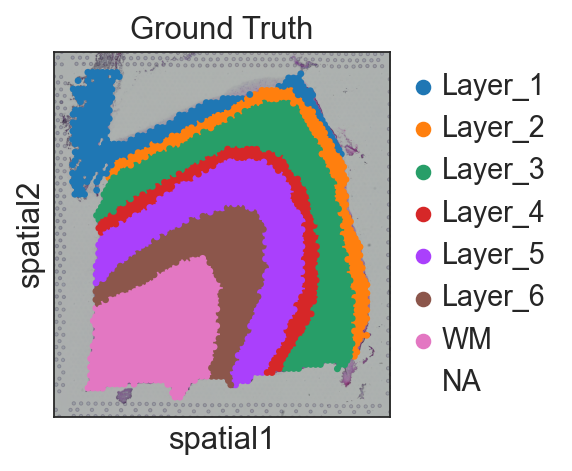

In [63]:
sc.pl.spatial(adata, color='Ground Truth', size=2)

... storing 'MvDST_label' as categorical


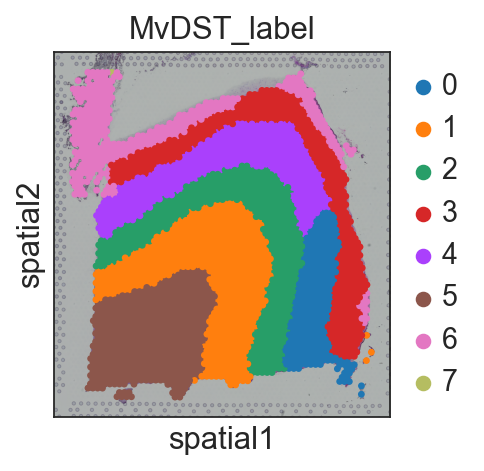

In [64]:
adata.obs['MvDST_label']=best_predicted_labels.astype(str)
sc.pl.spatial(adata, color='MvDST_label', size=2)

In [65]:
ARI = adjusted_rand_score(best_predicted_labels, pd.Categorical(enhanced_adata.obs['Ground Truth']).codes)
print('Adjusted rand index = %.3f' %ARI)

Adjusted rand index = 0.601


In [60]:
denoised_adata = enhanced_adata

In [52]:
denoised_adata.X = best_decoder_output
denoised_adata.obs["Ground Truth"]=enhanced_adata.obs["Ground Truth"]
denoised_adata.obs['MvDST_label']=best_predicted_labels.astype(str)
denoised_adata.obsm['feature']= latent_feature

computing neighbors
computing PCA
    with n_comps=50
    finished (0:00:01)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)


... storing 'MvDST_label' as categorical
... storing 'gene_ids' as categorical


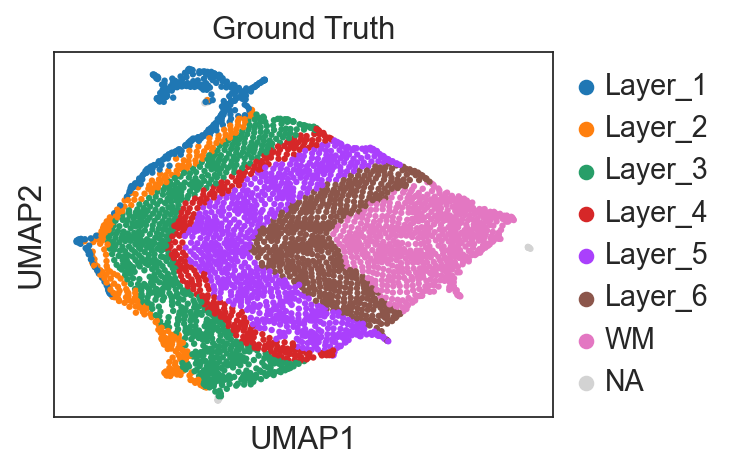

In [53]:
sc.pp.neighbors(denoised_adata)
sc.tl.umap(denoised_adata)
sc.pl.umap(denoised_adata, color=[ "Ground Truth"])

In [54]:
denoised_adata.obs['Ground Truth'] = denoised_adata.obs['Ground Truth'].astype('str')
denoised_adata.obs['Ground Truth'] = denoised_adata.obs['Ground Truth'].astype('category')

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


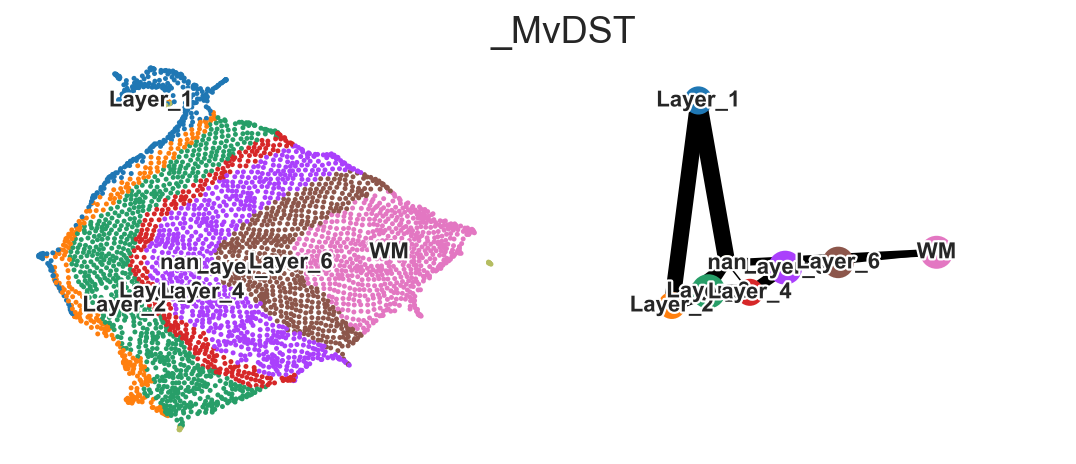

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [55]:
sc.tl.paga(denoised_adata, groups='Ground Truth')
plt.rcParams["figure.figsize"] = (4,3)
sc.pl.paga_compare(denoised_adata, legend_fontsize=10, frameon=False, size=20,
                   title='_MvDST', legend_fontoutline=2)